## Звіт про практичну роботу 3.3

### USA-Israel-Iran war history & Analysis (1948-2026)

**Завантажити та переглянути дані**:

In [33]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('war_history_economics_1948_2026.csv')

# Перегляд перших рядків
print(df.head())

# Огляд інформації про набір даних
print(df.info())


   Year Country  Military_Expenditure_Billion_USD  Active_Personnel  \
0  1948     USA                             50.97           1421958   
1  1949     USA                             47.01           1437337   
2  1950     USA                             75.96           2800000   
3  1951     USA                             78.28           2800000   
4  1952     USA                             96.22           2800000   

   GDP_Growth_Percent  Inflation_Rate_Percent  Conflict_Severity_Index  \
0                1.40                    4.55                        0   
1                3.06                    6.03                        2   
2                2.97                    3.35                        7   
3                2.54                    1.72                        7   
4                2.94                    0.70                        7   

  Significant_Event  
0               NaN  
1               NaN  
2        Korean War  
3        Korean War  
4        Korean Wa

**Очищення даних**:

In [34]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('war_history_economics_1948_2026.csv')

# ==========================================
# 1. Перевірка пропущених значень
# ==========================================

print("Пропущені значення у кожному стовпці:")
print(df.isnull().sum())

print("\nКількість рядків до очищення:", len(df))

# 2. Заповнення пропущених значень
# ==========================================

# Для числових стовпців заповнюємо пропуски медіаною
numeric_columns = df.select_dtypes(include=['number']).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Для категоріальних стовпців заповнюємо пропуски найчастішим значенням
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

# 3. Перевірка результату
# ==========================================

print("\nПропущені значення після заповнення:")
print(df.isnull().sum())


# ==========================================
# 4. Видалення дублікатів
# ==========================================

duplicates = df.duplicated().sum()

print("\nКількість дублікатів:", duplicates)

df = df.drop_duplicates()

print("Кількість рядків після видалення дублікатів:", len(df))


# ==========================================
# 5. Перетворення категоріальних змінних
# ==========================================

# Перевіряємо категоріальні стовпці
print("\nКатегоріальні стовпці:")
print(df.select_dtypes(include=['object', 'category']).columns.tolist())

# One-hot encoding для категоріальних змінних
df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include=['object', 'category']).columns,
    drop_first=True
)


# ==========================================
# 6. Перевірка очищеного набору даних
# ==========================================

print("\nІнформація про очищений набір даних:")
print(df.info())

print("\nПерші 5 рядків очищених даних:")
print(df.head())

Пропущені значення у кожному стовпці:
Year                                  0
Country                               0
Military_Expenditure_Billion_USD      0
Active_Personnel                      0
GDP_Growth_Percent                    0
Inflation_Rate_Percent                0
Conflict_Severity_Index               0
Significant_Event                   175
dtype: int64

Кількість рядків до очищення: 237

Пропущені значення після заповнення:
Year                                0
Country                             0
Military_Expenditure_Billion_USD    0
Active_Personnel                    0
GDP_Growth_Percent                  0
Inflation_Rate_Percent              0
Conflict_Severity_Index             0
Significant_Event                   0
dtype: int64

Кількість дублікатів: 0
Кількість рядків після видалення дублікатів: 237

Категоріальні стовпці:
['Country', 'Significant_Event']

Інформація про очищений набір даних:
<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data colu

C:\Users\day2026\AppData\Local\Temp\ipykernel_9476\2969170645.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns
C:\Users\day2026\AppData\Local\Temp\ipykernel_9476\2969170645.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas

**Описова статистика**:

In [35]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('war_history_economics_1948_2026.csv')

# Вибір числових змінних
numeric_columns = df.select_dtypes(include='number').columns

print("Числові змінні:")
print(numeric_columns.tolist())

# ==========================================
# 1. Загальна описова статистика
# ==========================================

print("\nОписова статистика:")
print(df[numeric_columns].describe())


# ==========================================
# 2. Основні статистичні показники
# ==========================================

statistics = pd.DataFrame({
    'Середнє значення': df[numeric_columns].mean(),
    'Медіана': df[numeric_columns].median(),
    'Стандартне відхилення': df[numeric_columns].std()
})

print("\nОсновні статистичні показники:")
print(statistics)


Числові змінні:
['Year', 'Military_Expenditure_Billion_USD', 'Active_Personnel', 'GDP_Growth_Percent', 'Inflation_Rate_Percent', 'Conflict_Severity_Index']

Описова статистика:
             Year  Military_Expenditure_Billion_USD  Active_Personnel  \
count   237.00000                        237.000000      2.370000e+02   
mean   1987.00000                        128.744895      7.841433e+05   
std      22.85177                        252.881599      6.956255e+05   
min    1948.00000                          0.500000      1.406980e+05   
25%    1967.00000                          2.310000      1.867320e+05   
50%    1987.00000                          6.130000      4.531770e+05   
75%    2007.00000                        132.150000      1.396601e+06   
max    2026.00000                       1171.360000      3.000000e+06   

       GDP_Growth_Percent  Inflation_Rate_Percent  Conflict_Severity_Index  
count          237.000000              237.000000               237.000000  
mean       

**Візуалізація даних**:

Числові змінні:
['Year', 'Military_Expenditure_Billion_USD', 'Active_Personnel', 'GDP_Growth_Percent', 'Inflation_Rate_Percent', 'Conflict_Severity_Index']


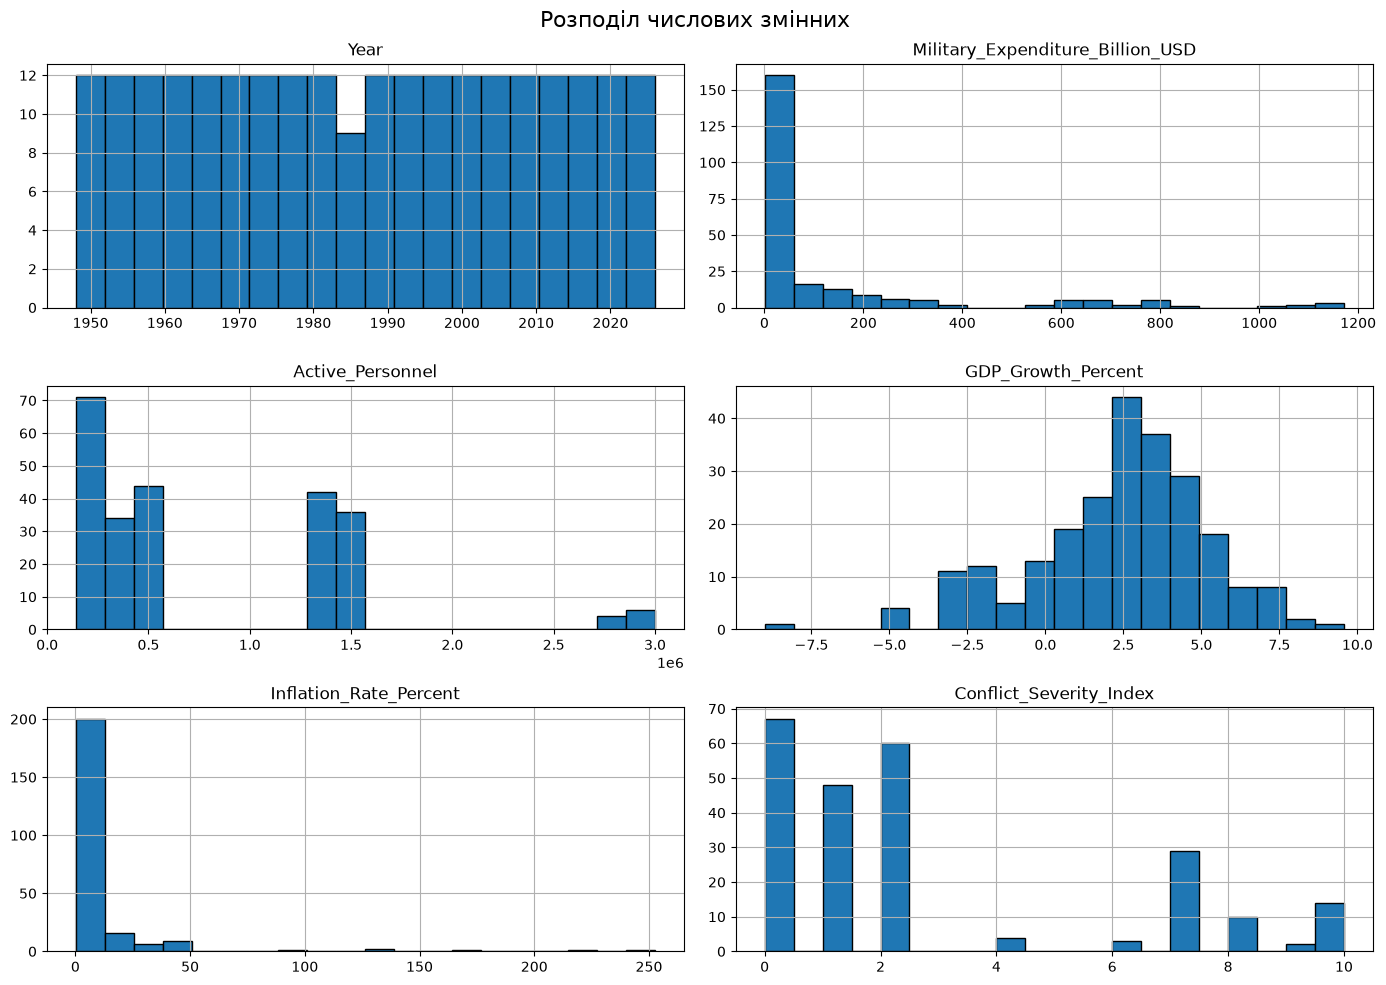

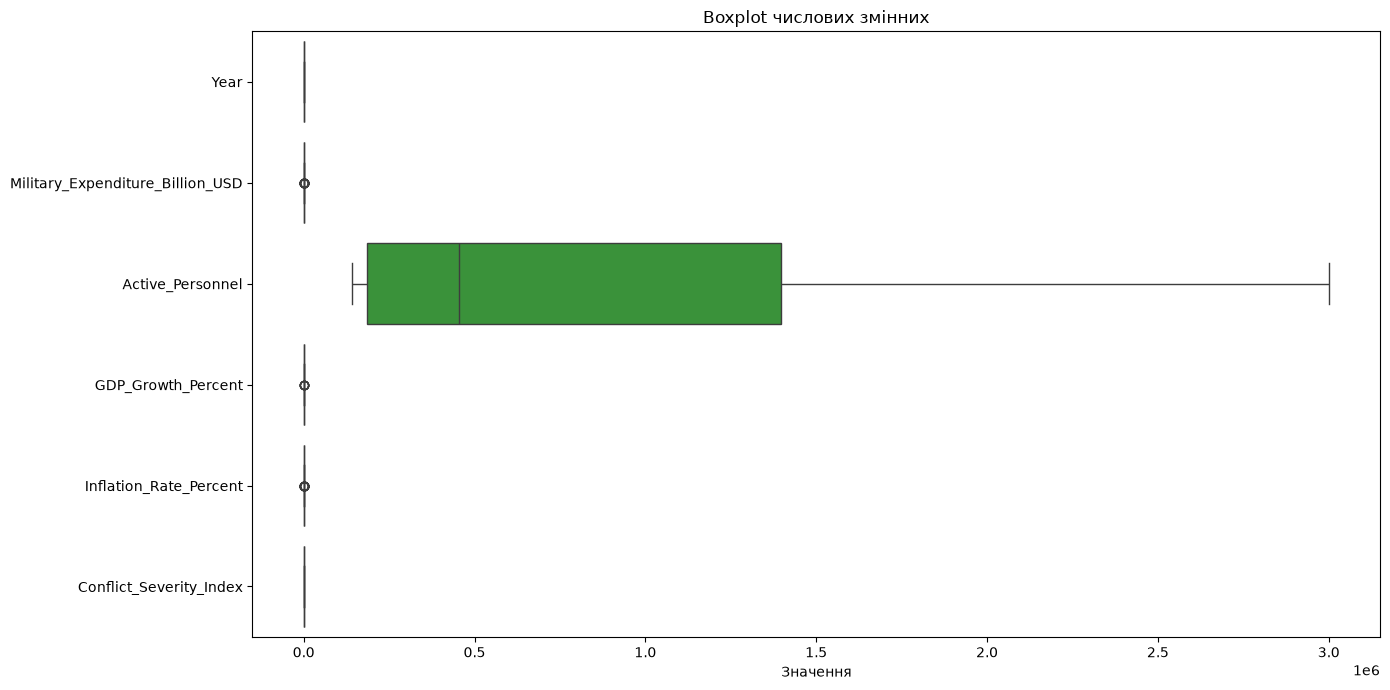

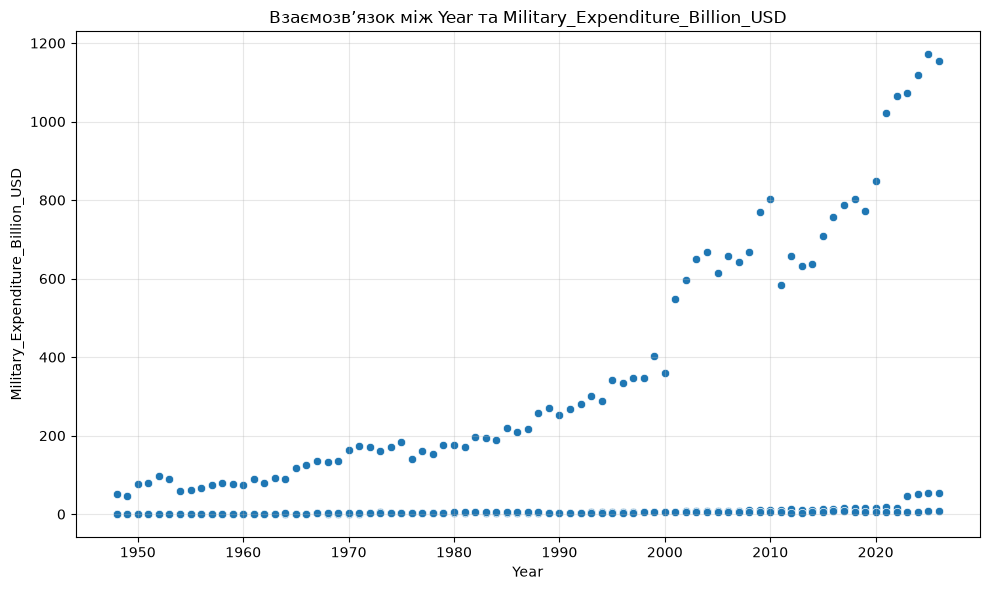

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('war_history_economics_1948_2026.csv')

# Отримуємо числові стовпці
numeric_columns = df.select_dtypes(include='number').columns

print("Числові змінні:")
print(numeric_columns.tolist())


# ==========================================
# 1. Гістограми
# ==========================================

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Розподіл числових змінних', fontsize=16)
plt.tight_layout()
plt.show()


# ==========================================
# 2. Boxplot
# ==========================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[numeric_columns],
    orient='h'
)

plt.title('Boxplot числових змінних')
plt.xlabel('Значення')
plt.tight_layout()
plt.show()


# ==========================================
# 3. Діаграма розсіювання
# ==========================================

# Перевіряємо, чи є щонайменше 2 числові змінні
if len(numeric_columns) >= 2:

    x_column = numeric_columns[0]
    y_column = numeric_columns[1]

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=x_column,
        y=y_column
    )

    plt.title(f'Взаємозв’язок між {x_column} та {y_column}')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


**Кореляційний аналіз**:

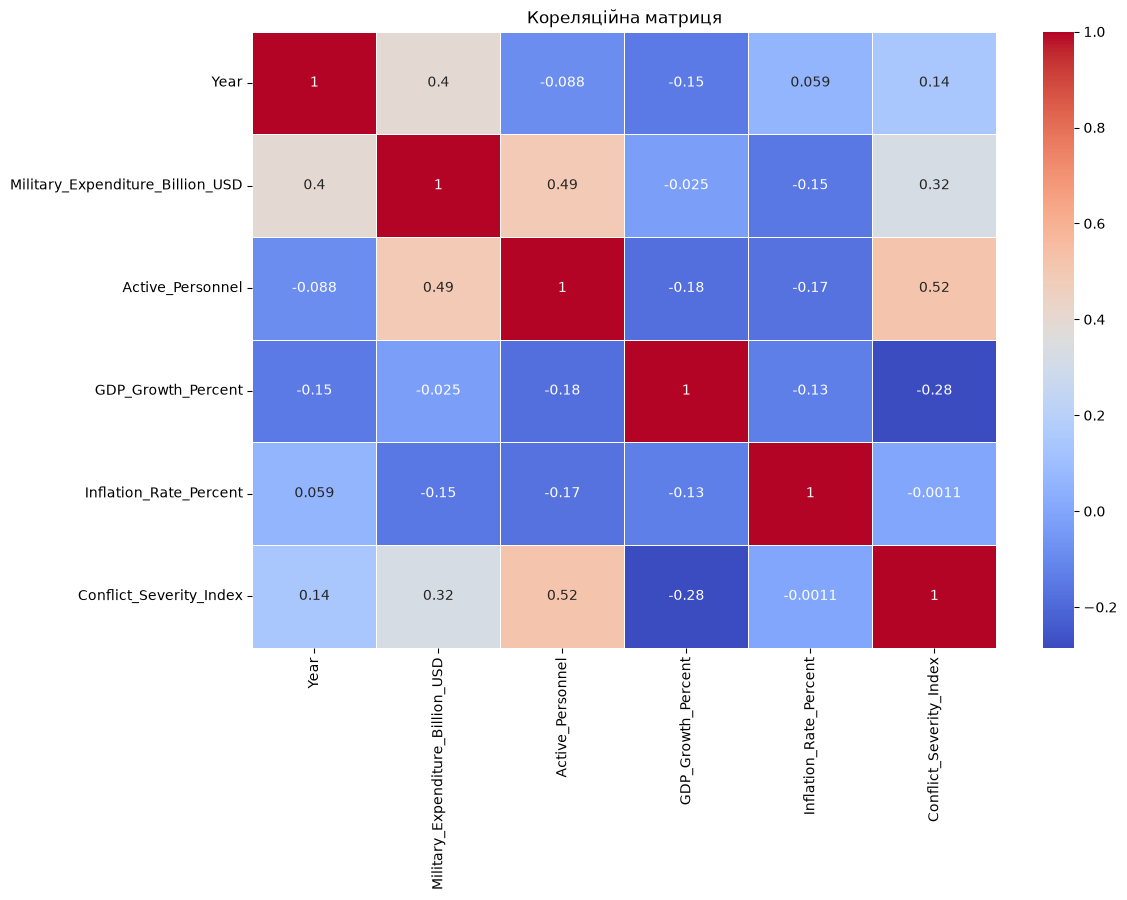

In [37]:
# Кореляційна матриця тільки для числових змінних
correlation_matrix = df.corr(numeric_only=True)

# Візуалізація
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Кореляційна матриця')
plt.show()